# PT3S
Use SIR 3S Modeldata and SIR 3S Results in pure Python.

With pandas, matplotlib and others.

For documentation, test, verification, analysis, reporting, prototyping, play.

## Install
Python 3.5.2 (Anaconda 4.2.0 (64-bit))

In [ ]:
!pip uninstall --yes PT3S
!pip install PT3S

## PT3S Imports

In [ ]:
%pwd

In [1]:
# currentWorkingDirectory should be after Kernel (Re-)Start the notebookDir 
# in this case PT3SSourcecodeDir (the Dir with PT3S' __init__.py and PT3S.ipynb (this notebook))

# PT3S-Imports:
# only if
# !pip install -e .
# is active 
# then _before the PT3S Imports the currentWorkingDirectory _has to be changed to .. PT3SSourcecodeDir  
%cd -q ..
from PT3S import Mx,Xm,Rm
%cd -q PT3S 
# if !pip install -e . is active the cd-Change has no effect  

# Imports

In [2]:
import unittest
import doctest

# Test Mx

In [3]:
# run the tests ...
unittest.TextTestRunner().run(doctest.DocTestSuite(Mx))  

.
----------------------------------------------------------------------
Ran 1 test in 2.958s

OK


<unittest.runner.TextTestResult run=1 errors=0 failures=0>

# Test Xm

In [4]:
# run the tests ...
unittest.TextTestRunner().run(doctest.DocTestSuite(Xm))  

.
----------------------------------------------------------------------
Ran 1 test in 11.522s

OK


<unittest.runner.TextTestResult run=1 errors=0 failures=0>

# Test Rm

In [5]:
# run the tests ...
unittest.TextTestRunner().run(doctest.DocTestSuite(Rm))  

.
----------------------------------------------------------------------
Ran 1 test in 3.082s

OK


<unittest.runner.TextTestResult run=1 errors=0 failures=0>

# Rm Plot Beispiele

## Vorbereitung

In [2]:
# ---
# Imports
# ---
import logging
logger = logging.getLogger('PT3S')  
import os
import pandas as pd
import matplotlib.pyplot as plt
path = os.path.dirname('.')

# ---
# LocalHeatingNetwork
# ---
xmlFile=os.path.join(path,'testdata\LocalHeatingNetwork.XML')
xm=Xm.Xm(xmlFile=xmlFile)
mx1File=os.path.join(path,'testdata\WDLocalHeatingNetwork\B1\V0\BZ1\M-1-0-1.MX1')
mx=Mx.Mx(mx1File=mx1File,NoH5Read=True,NoMxsRead=True)
mx.setResultsToMxsFile(NewH5Vec=True)
rm=Rm.Rm(xm=xm,mx=mx)

## Bsp1: Prozentdarstellung - keine Klassen

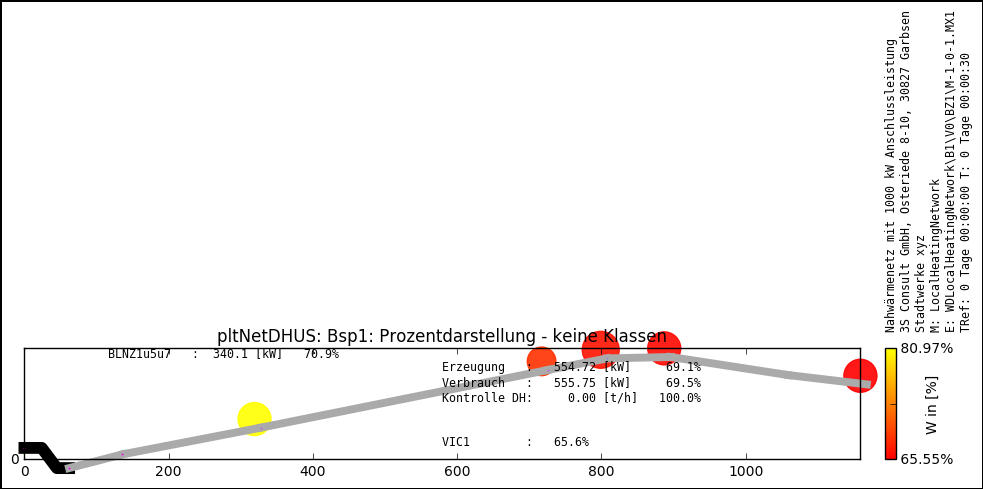

In [7]:
plt.close('all')
fig=plt.figure(dpi=2*72,linewidth=1.)
# 3Classes und FixedLimits sind standardmaessig Falsch; RefPerc ist standardmaessig Wahr
pFWVB=rm.pltNetDHUS(                                  
                 pltTitle='pltNetDHUS: Bsp1: Prozentdarstellung - keine Klassen'   
                ,timeDeltaToT= pd.to_timedelta('30 seconds')  
                ,pFIGNrcv=['WBLZ~WärmeblnzGes~\S*~\S+~WES'
                          ,'WBLZ~WärmeblnzGes~\S*~\S+~WVB'
                          ,'KNOT~PKON-Knoten~\S*~\S+~QM'
                          ]
                 ,pFIGNrcvTxt=['Erzeugung'
                              ,'Verbrauch'
                              ,'Kontrolle DH'
                              ]         
                 ,CBShrink=1. # default: 0.3; ist hier wg. der ausgepraegten Querformat-Modellausdehnung zu klein 
                 ,CBLabelPad=-20 # default: -50; dito zu gross
                     
                   )
plt.show()

## Bsp2: Prozentdarstellung - Klassen

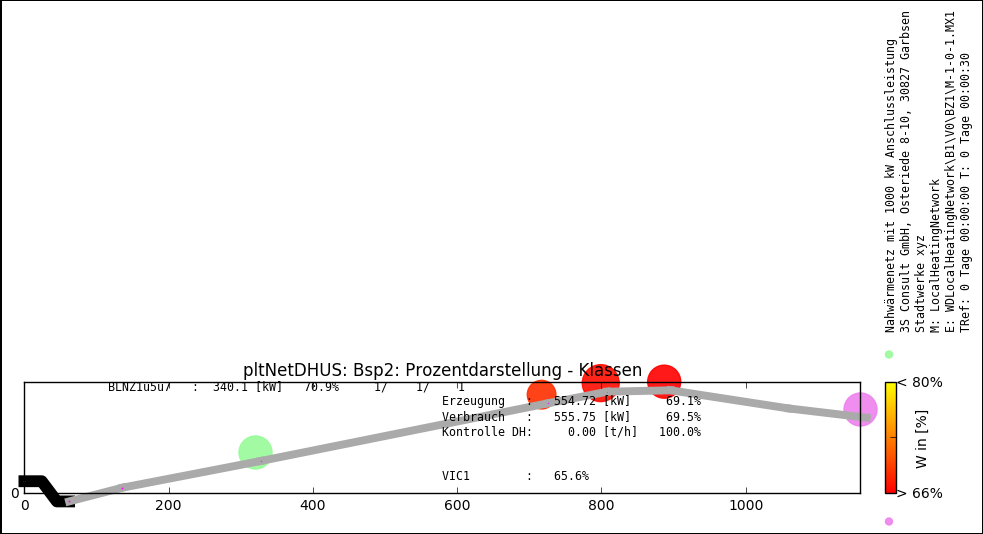

In [8]:
plt.close('all')
fig=plt.figure(dpi=2*72,linewidth=1.)
# 3Classes und FixedLimits sind standardmaessig Falsch; RefPerc ist standardmaessig Wahr
pFWVB=rm.pltNetDHUS(                   
                 pltTitle='pltNetDHUS: Bsp2: Prozentdarstellung - Klassen'   
                ,timeDeltaToT= pd.to_timedelta('30 seconds')  
    
                ,pFIGNrcv=['WBLZ~WärmeblnzGes~\S*~\S+~WES'
                          ,'WBLZ~WärmeblnzGes~\S*~\S+~WVB'
                          ,'KNOT~PKON-Knoten~\S*~\S+~QM'
                          ]
                 ,pFIGNrcvTxt=['Erzeugung'
                              ,'Verbrauch'
                              ,'Kontrolle DH'
                              ]         
                 ,CBShrink=1. # default: 0.3; ist hier wg. der ausgepraegten Querformat-Modellausdehnung zu klein 
                 ,CBLabelPad=-20 # default: -50; dito zu gross
    
                 ,pFWVBMeasure3Classes=True
                 ,pFWVBMeasureCBFixedLimitHigh=0.80
                 ,pFWVBMeasureCBFixedLimitLow=0.66
                   )
plt.show()

## Bsp3: keine Prozentdarstellung - Klassen

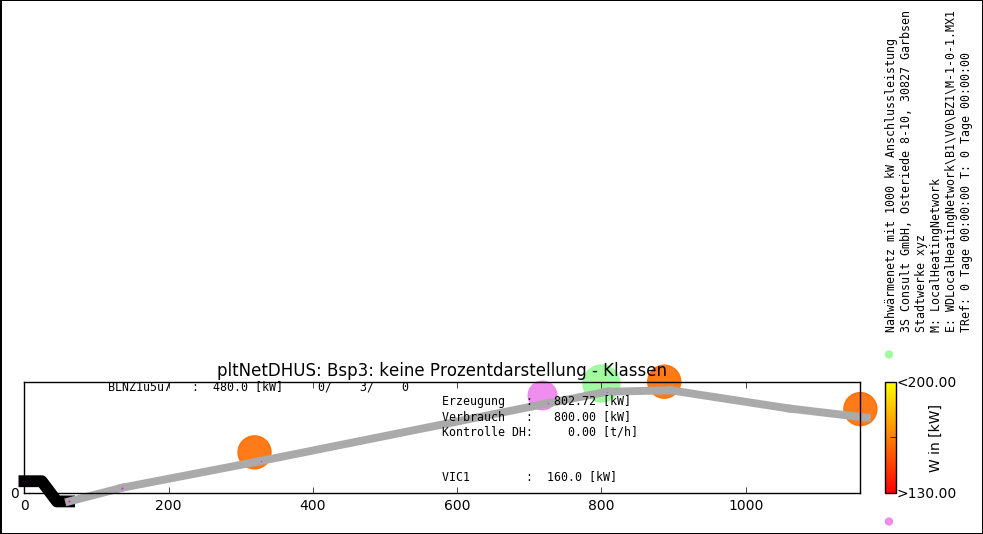

In [9]:
plt.close('all')
fig=plt.figure(dpi=2*72,linewidth=1.)
# 3Classes und FixedLimits sind standardmaessig Falsch; RefPerc ist standardmaessig Wahr
pFWVB=rm.pltNetDHUS(         
                 pltTitle='pltNetDHUS: Bsp3: keine Prozentdarstellung - Klassen'                   
                ,pFIGNrcv=['WBLZ~WärmeblnzGes~\S*~\S+~WES'
                          ,'WBLZ~WärmeblnzGes~\S*~\S+~WVB'
                          ,'KNOT~PKON-Knoten~\S*~\S+~QM'
                          ]
                 ,pFIGNrcvTxt=['Erzeugung'
                              ,'Verbrauch'
                              ,'Kontrolle DH'
                              ]         
                 ,CBShrink=1. # default: 0.3; ist hier wg. der ausgepraegten Querformat-Modellausdehnung zu klein 
                 ,CBLabelPad=-20 # default: -50; dito zu gross
    
                 ,pFWVBMeasure3Classes=True
                 ,pFWVBMeasureInRefPerc=False  
                 ,pFWVBMeasure='FWVB~*~*~*~W' 
                 
                 ,pFWVBMeasureCBFixedLimitHigh=200.
                 ,pFWVBMeasureCBFixedLimitLow=130.
                   )
plt.show()

# Deploy

python setup.py clean sdist bdist_wheel 

pip install twine

twine upload dist/*

# Develop

In [ ]:
!pip install -e .

due to ...\Lib\site-packages\PT3S.egg-link

import PT3S 

will work (if PythonShell is executed .. PT3SSourcecodeDir)

and point to _local PT3SSourcecodeDir

Repository: https://github.com/aw3s/PT3S.git

In [3]:
import pandas as pd

In [ ]:
df = pd.DataFrame({'animal': 'cat dog cat fish dog cat cat'.split(),
....: 'size': list('SSMMMLL'),
....: 'weight': [8, 10, 11, 1, 20, 12, 12],
....: 'adult' : [False] * 5 + [True] * 2}); df

In [ ]:
f=lambda df: (df.KVR.isin([2])) & (df.CONT_ID.isin([1001]))

In [ ]:
f=lambda subf: (subf['size']=='S') & (subf['weight']>8)

In [ ]:
df.loc[f]

In [ ]:
df[f]

In [ ]:
df=xm.dataFrames['vROHR']

In [ ]:
f=lambda df: (df.KVR.isin([2])) & (df.CONT_ID.isin([1001]))

In [ ]:
df.KVR.astype(int)

In [ ]:
f=lambda df: (df.KVR.astype(int).isin([2])) & (df.CONT_ID.astype(int).isin([1001]))

In [ ]:
df[f]

In [ ]:
f=lambda df: True

In [4]:
vAGSN=xm.dataFrames['AGSN']

In [7]:
vAGSN

,AKTIV,LAYOUT_XML,LFDNR,NAME,OBJS,fkDE,pk,rk,tk
0,101,PExheW91dD4NCiAgPERJQUdSQU0+DQogICAgPFBLX0RCPj...,1,Netzdruckdiagramm VL/RL: BHKW - Netzende,ROHR~4939422678063487923\t\tROHR~4984202422877...,5758799913943400110,5252525269080005909,5252525269080005909,5252525269080005909


In [6]:
import base64
vAGSN['OBJS']=vAGSN['OBJS'].apply(lambda x: base64.b64decode(x)).str.decode('utf-8')

In [17]:
vAGSN['LAYOUT_XML']=vAGSN['LAYOUT_XML'].apply(lambda x: base64.b64decode(x)).str.decode('utf-8')

In [ ]:
LAYR=xm.dataFrames['LAYR']

In [20]:
vAGSN.LAYOUT_XML.iloc[0]

'<Layout>\r\n  <DIAGRAM>\r\n    <PK_DB>5252525269080005909</PK_DB>\r\n    <RK_DB>5252525269080005909</RK_DB>\r\n    <TITLE>Netzdruckdiagramm VL/RL: BHKW - Netzende</TITLE>\r\n    <TYPE>3</TYPE>\r\n    <LINES_PER_GAP>2</LINES_PER_GAP>\r\n    <AVOID_SLACK_LINE>0</AVOID_SLACK_LINE>\r\n    <IDPH_DIM_TABLE_RA>0</IDPH_DIM_TABLE_RA>\r\n    <IDPH_DIM_TABLE_PRESSURES>2</IDPH_DIM_TABLE_PRESSURES>\r\n    <WATER_PRESSURE_DIMENSION>0</WATER_PRESSURE_DIMENSION>\r\n    <OVERVIEW>0</OVERVIEW>\r\n    <SHOW_NODE_NAMES>1</SHOW_NODE_NAMES>\r\n    <SHOW_KM>1</SHOW_KM>\r\n    <SHOW_DIAMETERS>1</SHOW_DIAMETERS>\r\n    <SHOW_PUMP>1</SHOW_PUMP>\r\n    <SHOW_KLAP>1</SHOW_KLAP>\r\n    <SHOW_REGV>1</SHOW_REGV>\r\n    <SHOW_VENT>0</SHOW_VENT>\r\n    <SHOW_BEVE>1</SHOW_BEVE>\r\n    <SHOW_BEWI>1</SHOW_BEWI>\r\n    <SHOW_OBEH>1</SHOW_OBEH>\r\n    <SHOW_STRO>1</SHOW_STRO>\r\n    <SHOW_WIND>1</SHOW_WIND>\r\n    <SHOW_ACT_P>1</SHOW_ACT_P>\r\n    <SHOW_PIPE_AXIS>1</SHOW_PIPE_AXIS>\r\n    <SHOW_STAT_PRESSURE_LINE>0</SHOW_

In [ ]:
print(LAYOUT_XML)